
On average: 10 simulations of 100000 games each:
 - Player A lost: 54.538 % of the games.
 - Player B lost: 45.462 % of the games.

Player A has lost 9.076 % of the games more than player B.


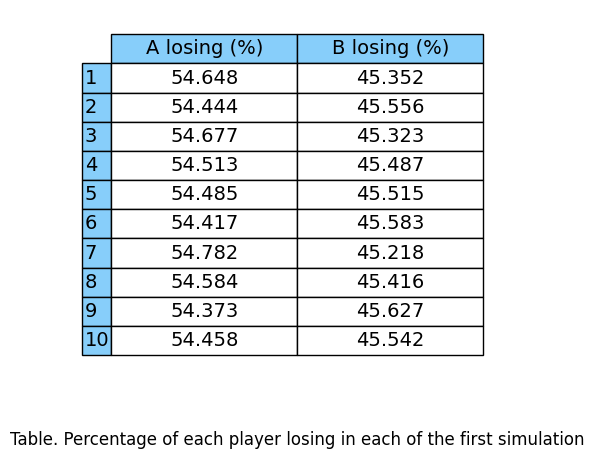


On average: 10 simulations of 100000 games each:
 - Player A lost: 60.07 % of the games.
 - Player B lost: 39.93 % of the games.

Player A has lost 20.14 % of the games more than player B.


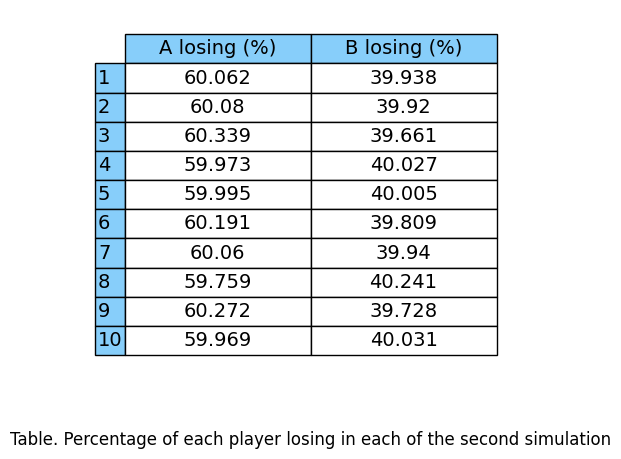


On average: 10 simulations of 100000 games each:
 - Player A lost: 66.737 % of the games.
 - Player B lost: 33.263 % of the games.

Player A has lost 33.474 % of the games more than player B.


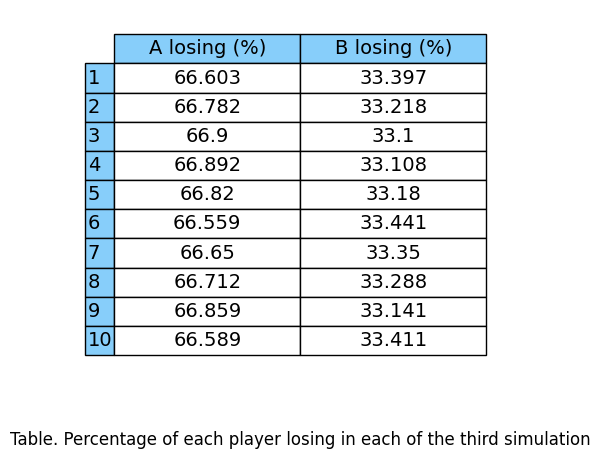


On average: 10 simulations of 100000 games each:
 - Player A lost: 60.042 % of the games.
 - Player B lost: 39.958 % of the games.

Player A has lost 20.084 % of the games more than player B.


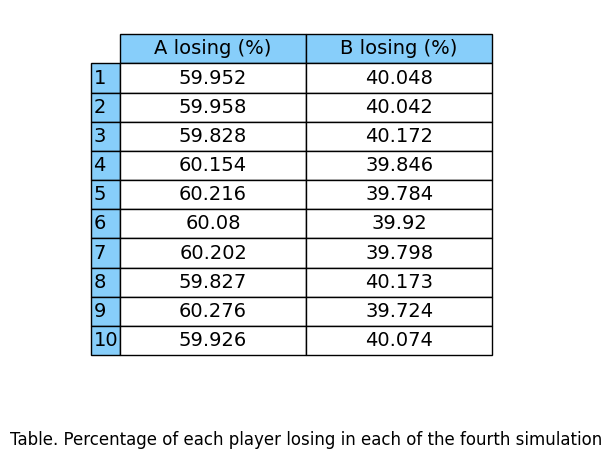

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Function to run the simulation 'num' times
# Each simulation has 'gameTotal' games
def simulation(num,gameTotal):
    
    gameTotalLost_A = 0
    gameTotalLost_B = 0
    percentageLostArray_A = np.empty(0,float)
    percentageLostArray_B = np.empty(0,float)
    
    for sim in range (0,num):
        # Counter for the game lost by each players
        gameLost_A = 0
        gameLost_B = 0

        for game in range (0,gameTotal):
            # print ("Game", game, ":")
            gameEnd = bool(False)
            count = 1

            while(gameEnd == False):
                # Random the integer 'x' in the set of {0,1,2,3,4,5}
                # 'x' has 1/6 chance to be 0, which is chose to be when the weapon discharges
                x = random.randint(0,5)        
                if(x == 0):
                    if (count % 2 == 0):
                        # When the integer 'count' is even and 'x' is randomized to equal 0, which means player B lost
                        # Increment for the counter which B loses
                        gameLost_B += 1
                    else:
                        # Increment for the counter which A loses
                        gameLost_A += 1                
                    # Boolean to check whether the game is finished
                    gameEnd = True
                else:
                    # Increment for the integer 'count'
                    count += 1

        #print("\nSimulation", sim+1, ":", "In", gameTotal, "games:")
        #print("Player A lost:", gameLost_A, "times, accounting for", round(gameLost_A/gameTotal*100,3), "% of the games.")
        #print("Player B lost:", gameLost_B, "times, accounting for", round(gameLost_B/gameTotal*100,3), "% of the games.")
        gameTotalLost_A += gameLost_A
        gameTotalLost_B += gameLost_B
        percentageLostArray_A = np.append(percentageLostArray_A, [round(gameLost_A/gameTotal*100,3)], axis=0)
        percentageLostArray_B = np.append(percentageLostArray_B, [round(gameLost_B/gameTotal*100,3)], axis=0)
        
    percentageLostAverage_A = round(gameTotalLost_A/(gameTotal*num)*100,3)
    percentageLostAverage_B = round(gameTotalLost_B/(gameTotal*num)*100,3)
    print("\nOn average:", sim+1, "simulations of", gameTotal, "games each:")
    print(" - Player A lost:", percentageLostAverage_A, "% of the games.")
    print(" - Player B lost:", percentageLostAverage_B, "% of the games.")
    
    print("\nPlayer A has lost", round(percentageLostAverage_A - percentageLostAverage_B,3), "% of the games more than player B.")
    
    return percentageLostAverage_A, percentageLostAverage_B, percentageLostArray_A, percentageLostArray_B

# Run the simulation() function
num = int(input("Number of the 1st simulations (1 loaded chamber & the cylinder is re-spun every turn): "))
P_A, P_B, Array_A, Array_B = simulation(num,100000)


# In[ ]:


import pandas as pd

Array_combined = np.vstack((Array_A, Array_B)).T

fig, ax = plt.subplots(1,1)

column_labels=["A losing (%)", "B losing (%)"]
df = pd.DataFrame(Array_combined, columns=column_labels)
ax.axis('off')

table = ax.table(cellText=df.values,
        colLabels=df.columns,
        rowLabels=[x+1 for x in range (0,num)],
        rowColours =["lightskyblue"] * 10,  
        colColours =["lightskyblue"] * 2,
        colWidths=[.5]*2,
        cellLoc="center",
        loc="center")
table.set_fontsize(14)
table.scale(0.75, 1.75)

plt.title("Table. Percentage of each player losing in each of the first simulation", y=-0.2)
plt.show()


# ## The second simulation: 2 adjacent loaded chambers and the cylinder is re-spun every turn

# The function simulation(num, gameTotal) is changed into simulation2(num, gameTotal) with 0 and 1 are the two numbers used to determine when the one of the two loaded chamber is triggered. The odds of one of the two numbers being randomized are 2/6 (33.33%).

# In[ ]:


import random
import numpy as np
import matplotlib.pyplot as plt

def simulation2(num,gameTotal):
    
    gameTotalLost_A = 0
    gameTotalLost_B = 0
    percentageLostArray_A = np.empty(0,float)
    percentageLostArray_B = np.empty(0,float)
    
    for sim in range (0,num):
        # Counter for the game lost by each players
        gameLost_A = 0
        gameLost_B = 0

        for game in range (0,gameTotal):
            # print ("Game", game, ":")
            gameEnd = bool(False)
            count = 1

            while(gameEnd == False):
                # Random the integer 'x' in the set of {0,1,2,3,4,5}
                # 'x' has 2/6 chance to be 0 or 1, which is chose to be when the weapon discharges
                x = random.randint(0,5)        
                if((x == 0) or (x == 1)):
                    if (count % 2 == 0):
                        # When the integer 'count' is even and 'x' is randomized to equal 0, which means player B lost
                        # Increment for the counter which B loses
                        gameLost_B += 1
                    else:
                        # Increment for the counter which A loses
                        gameLost_A += 1                
                    # Boolean to check whether the game is finished
                    gameEnd = True
                else:
                    # Increment for the integer 'count'
                    count += 1

        #print("\nSimulation", sim+1, ":", "In", gameTotal, "games:")
        #print("Player A lost:", gameLost_A, "times, accounting for", round(gameLost_A/gameTotal*100,3), "% of the games.")
        #print("Player B lost:", gameLost_B, "times, accounting for", round(gameLost_B/gameTotal*100,3), "% of the games.")
        gameTotalLost_A += gameLost_A
        gameTotalLost_B += gameLost_B
        percentageLostArray_A = np.append(percentageLostArray_A, [round(gameLost_A/gameTotal*100,3)], axis=0)
        percentageLostArray_B = np.append(percentageLostArray_B, [round(gameLost_B/gameTotal*100,3)], axis=0)
        
    percentageLostAverage_A = round(gameTotalLost_A/(gameTotal*num)*100,3)
    percentageLostAverage_B = round(gameTotalLost_B/(gameTotal*num)*100,3)
    print("\nOn average:", sim+1, "simulations of", gameTotal, "games each:")
    print(" - Player A lost:", percentageLostAverage_A, "% of the games.")
    print(" - Player B lost:", percentageLostAverage_B, "% of the games.")
    
    print("\nPlayer A has lost", round(percentageLostAverage_A - percentageLostAverage_B,3), "% of the games more than player B.")
    
    return percentageLostAverage_A, percentageLostAverage_B, percentageLostArray_A, percentageLostArray_B

# Run the simulation() function
num = int(input("Number of the 2nd simulations (2 adjacent loaded chambers & the cylinder is re-spun every turn): "))
P_A, P_B, Array_A, Array_B = simulation2(num,100000)


# In[ ]:


import pandas as pd

Array_combined = np.vstack((Array_A, Array_B)).T

fig, ax = plt.subplots(1,1)

column_labels=["A losing (%)", "B losing (%)"]
df = pd.DataFrame(Array_combined, columns=column_labels)
ax.axis('off')

table = ax.table(cellText=df.values,
        colLabels=df.columns,
        rowLabels=[x+1 for x in range (0,num)],
        rowColours =["lightskyblue"] * 10,  
        colColours =["lightskyblue"] * 2,
        colWidths=[.5]*2,
        cellLoc="center",
        loc="center")
table.set_fontsize(14)
table.scale(0.75, 1.75)

plt.title("Table. Percentage of each player losing in each of the second simulation", y=-0.2)
plt.show()


# ## The third simulation: 2 adjacent loaded chambers and the cylinder NOT is re-spun every turn

# The function is one more time changed into simulation3(num, gameTotal) with 2 adjacent randomized numbers for the two loaded chambers (if the first number is 5 then the second number will be 0). A new number, the starting chamber, is randomized, and this number increases by 1 every turn. If this number gets to 5, the last chamber, and the game still doesn't end, the number is looped back to 0.

# In[ ]:


import random
import numpy as np
import matplotlib.pyplot as plt

def simulation3(num,gameTotal):
    
    gameTotalLost_A = 0
    gameTotalLost_B = 0
    percentageLostArray_A = np.empty(0,float)
    percentageLostArray_B = np.empty(0,float)
    
    for sim in range (0,num):
        # Counter for the game lost by each players
        gameLost_A = 0
        gameLost_B = 0

        for game in range (0,gameTotal):
            # print ("Game", game, ":")
            gameEnd = bool(False)
            count = 1            
            
            # Random two loaded chambers
            chamber_1 = random.randint(0,5)
            chamber_2 = chamber_1 + 1
            
            # Checking whether the second chamber is out of the range {0,5}
            if (chamber_2 > 5):
                chamber_2 = 0
                
            # Initialize the starting chamber                
            x = random.randint(0,5)

            while(gameEnd == False):
                
                if((x == chamber_1) or (x == chamber_2)):
                    if (count % 2 == 0):
                        # When the integer 'count' is even and 'x' is randomized to equal 0, which means player B lost
                        # Increment for the counter which B loses
                        gameLost_B += 1
                    else:
                        # Increment for the counter which A loses
                        gameLost_A += 1                
                    # Boolean to check whether the game is finished
                    gameEnd = True
                else:
                    # Increment for the integer 'count'
                    count += 1
                    
                # If x=5 and game still doesn't end, loop back to x=0. Else increase x by 1
                if (x == 5):
                    x = 0
                else:
                    x += 1

        #print("\nSimulation", sim+1, ":", "In", gameTotal, "games:")
        #print("Player A lost:", gameLost_A, "times, accounting for", round(gameLost_A/gameTotal*100,3), "% of the games.")
        #print("Player B lost:", gameLost_B, "times, accounting for", round(gameLost_B/gameTotal*100,3), "% of the games.")
        gameTotalLost_A += gameLost_A
        gameTotalLost_B += gameLost_B
        percentageLostArray_A = np.append(percentageLostArray_A, [round(gameLost_A/gameTotal*100,3)], axis=0)
        percentageLostArray_B = np.append(percentageLostArray_B, [round(gameLost_B/gameTotal*100,3)], axis=0)
        
    percentageLostAverage_A = round(gameTotalLost_A/(gameTotal*num)*100,3)
    percentageLostAverage_B = round(gameTotalLost_B/(gameTotal*num)*100,3)
    print("\nOn average:", sim+1, "simulations of", gameTotal, "games each:")
    print(" - Player A lost:", percentageLostAverage_A, "% of the games.")
    print(" - Player B lost:", percentageLostAverage_B, "% of the games.")
    
    print("\nPlayer A has lost", round(percentageLostAverage_A - percentageLostAverage_B,3), "% of the games more than player B.")
    
    return percentageLostAverage_A, percentageLostAverage_B, percentageLostArray_A, percentageLostArray_B

# Run the simulation() function
num = int(input("Number of the 3rd simulations (2 adjacent loaded chambers & the cylinder NOT is re-spun every turn): "))
P_A, P_B, Array_A, Array_B = simulation3(num,100000)


# In[ ]:


import pandas as pd

Array_combined = np.vstack((Array_A, Array_B)).T

fig, ax = plt.subplots(1,1)

column_labels=["A losing (%)", "B losing (%)"]
df = pd.DataFrame(Array_combined, columns=column_labels)
ax.axis('off')

table = ax.table(cellText=df.values,
        colLabels=df.columns,
        rowLabels=[x+1 for x in range (0,num)],
        rowColours =["lightskyblue"] * 10,  
        colColours =["lightskyblue"] * 2,
        colWidths=[.5]*2,
        cellLoc="center",
        loc="center")
table.set_fontsize(14)
table.scale(0.75, 1.75)

plt.title("Table. Percentage of each player losing in each of the third simulation", y=-0.2)
plt.show()


# ## The fourth simulation: 2 random loaded chambers and the cylinder NOT is re-spun every turn

# The function simulation3(num, gameTotal) is changed into simulation4(num, gameTotal) with a little tweak this time. Instead of 2 adjacent randomized numbers, this time 2 different numbers are chosen to be the 2 loaded chambers.

# In[ ]:


import random
import numpy as np
import matplotlib.pyplot as plt

def simulation4(num,gameTotal):
    
    gameTotalLost_A = 0
    gameTotalLost_B = 0
    percentageLostArray_A = np.empty(0,float)
    percentageLostArray_B = np.empty(0,float)
    
    for sim in range (0,num):
        # Counter for the game lost by each players
        gameLost_A = 0
        gameLost_B = 0

        for game in range (0,gameTotal):
            # print ("Game", game, ":")
            gameEnd = bool(False)
            count = 1            
            
            # Random two loaded chambers
            chamber_1 = random.randint(0,5)
            chamber_2 = random.randint(0,5)
            
            # Checking whether the two random numbers are different            
            while (chamber_2 == chamber_1):
                chamber_2 = random.randint(0,5)
                
            # Initialize the starting chamber                
            x = random.randint(0,5)

            while(gameEnd == False):
                
                if((x == chamber_1) or (x == chamber_2)):
                    if (count % 2 == 0):
                        # When the integer 'count' is even and 'x' is randomized to equal 0, which means player B lost
                        # Increment for the counter which B loses
                        gameLost_B += 1
                    else:
                        # Increment for the counter which A loses
                        gameLost_A += 1                
                    # Boolean to check whether the game is finished
                    gameEnd = True
                else:
                    # Increment for the integer 'count'
                    count += 1
                    
                # If x=5 and game still doesn't end, loop back to x=0. Else increase x by 1
                if (x == 5):
                    x = 0
                else:
                    x += 1

        #print("\nSimulation", sim+1, ":", "In", gameTotal, "games:")
        #print("Player A lost:", gameLost_A, "times, accounting for", round(gameLost_A/gameTotal*100,3), "% of the games.")
        #print("Player B lost:", gameLost_B, "times, accounting for", round(gameLost_B/gameTotal*100,3), "% of the games.")
        gameTotalLost_A += gameLost_A
        gameTotalLost_B += gameLost_B
        percentageLostArray_A = np.append(percentageLostArray_A, [round(gameLost_A/gameTotal*100,3)], axis=0)
        percentageLostArray_B = np.append(percentageLostArray_B, [round(gameLost_B/gameTotal*100,3)], axis=0)
        
    percentageLostAverage_A = round(gameTotalLost_A/(gameTotal*num)*100,3)
    percentageLostAverage_B = round(gameTotalLost_B/(gameTotal*num)*100,3)
    print("\nOn average:", sim+1, "simulations of", gameTotal, "games each:")
    print(" - Player A lost:", percentageLostAverage_A, "% of the games.")
    print(" - Player B lost:", percentageLostAverage_B, "% of the games.")
    
    print("\nPlayer A has lost", round(percentageLostAverage_A - percentageLostAverage_B,3), "% of the games more than player B.")
    
    return percentageLostAverage_A, percentageLostAverage_B, percentageLostArray_A, percentageLostArray_B

# Run the simulation() function
num = int(input("Number of the 4th simulations (2 random loaded chambers & the cylinder NOT is re-spun every turn): "))
P_A, P_B, Array_A, Array_B = simulation4(num,100000)


# In[ ]:


import pandas as pd

Array_combined = np.vstack((Array_A, Array_B)).T

fig, ax = plt.subplots(1,1)

column_labels=["A losing (%)", "B losing (%)"]
df = pd.DataFrame(Array_combined, columns=column_labels)
ax.axis('off')

table = ax.table(cellText=df.values,
        colLabels=df.columns,
        rowLabels=[x+1 for x in range (0,num)],
        rowColours =["lightskyblue"] * 10,  
        colColours =["lightskyblue"] * 2,
        colWidths=[.5]*2,
        cellLoc="center",
        loc="center")
table.set_fontsize(14)
table.scale(0.75, 1.75)

plt.title("Table. Percentage of each player losing in each of the fourth simulation", y=-0.2)
plt.show()

